In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib as mpl
import shap
from matplotlib import cm

In [2]:
test = pd.read_excel('../../dataset/test set.xlsx')
PFAS_all = test["PFAS"].reset_index(drop=True)
tissue_all = test["Tissue"].reset_index(drop=True)
test['logIpc'] = np.log10(test['Ipc'])
test['logSRC'] = np.log10(test['Soil residual concentration'])
test['logED'] = np.log10(test['ED'])

In [3]:
test['logIpc'] = np.log10(test['Ipc'])
test.drop(columns=['Reference', 'Sample','Soil source','ES','PFAS','PFAS class','Species','Plant class','group','Ipc',
                   'ED','Soil residual concentration'], inplace=True)
x_test = test.drop(columns=['lnBCF'], errors='ignore').copy()
y_test = test['lnBCF'].copy()
cat_cols = [
    'Tissue',
    'Family','Genus','Order','monocot','woody','herb','crop','vegetable','legume','grass','perennial','edible'
]
cat_cols = [c for c in cat_cols if c in x_test.columns] 

In [4]:
model = CatBoostRegressor()
model.load_model("../../notebooks/Model/catboost_final.cbm")
y_pred = model.predict(x_test)

In [5]:
def metrics(y_true, y_pred, name='Result'):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f'\n{name}')
    print(f'R2   : {r2:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'MAE  : {mae:.4f}')

    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    }

In [6]:
metrics(y_test, y_pred)


Result
R2   : 0.8404
RMSE : 1.1070
MAE  : 0.8940


{'R2': 0.8403760489821382,
 'RMSE': np.float64(1.1070121302271818),
 'MAE': 0.8939890948447939}


Result
R2   : 0.8404
RMSE : 1.1070
MAE  : 0.8940


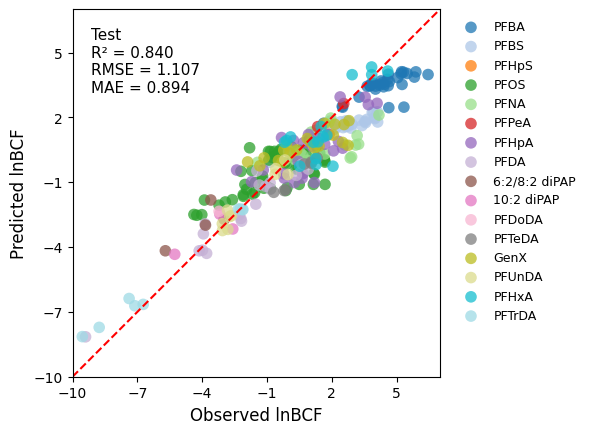

In [ ]:
plot_df = pd.DataFrame({
    "PFAS": PFAS_all,
    "Observed": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

pfas_types = plot_df["PFAS"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(pfas_types)))
color_dict = dict(zip(pfas_types, colors))

plt.figure(figsize=(6,6))


for pfas in pfas_types:
    sub = plot_df[plot_df["PFAS"] == pfas]

    plt.scatter(
        sub["Observed"],
        sub["Predicted"],
        alpha=0.75,
        s=70,
        color=color_dict[pfas],
        edgecolor='none',
        label=pfas
    )

min_val = min(plot_df["Observed"].min(), plot_df["Predicted"].min())
max_val = max(plot_df["Observed"].max(), plot_df["Predicted"].max())

min_val = np.floor(min_val)
max_val = np.ceil(max_val)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.gca().set_aspect('equal', adjustable='box')

ticks = np.arange(min_val, max_val + 1, 3)
plt.xticks(ticks)
plt.yticks(ticks)

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5)

test_metrics = metrics(y_test, y_pred)

plt.text(
    0.05, 0.95,
    f"Test\nR² = {test_metrics['R2']:.3f}\nRMSE = {test_metrics['RMSE']:.3f}\nMAE = {test_metrics['MAE']:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    fontsize=11
)

plt.xlabel("Observed lnBCF", fontsize=12)
plt.ylabel("Predicted lnBCF", fontsize=12)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
#plt.savefig("../../Fig/eps/Final_model_test.eps", dpi=600, bbox_inches="tight")
plt.show()


Result
R2   : 0.8404
RMSE : 1.1070
MAE  : 0.8940


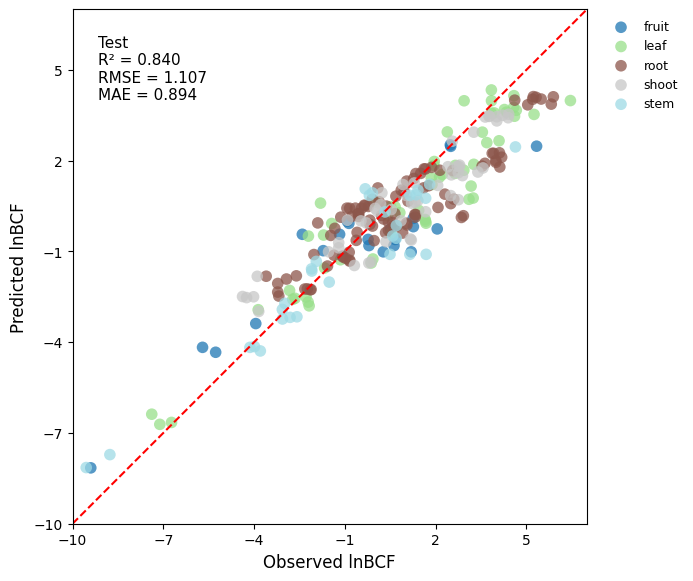

In [ ]:
plot_df = pd.DataFrame({
    "Tissue": tissue_all,
    "Observed": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

tissue_types = plot_df["Tissue"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(tissue_types)))
color_dict = dict(zip(tissue_types, colors))

plt.figure(figsize=(7,7))

for tissue in tissue_types:
    sub = plot_df[plot_df["Tissue"] == tissue]

    plt.scatter(
        sub["Observed"],
        sub["Predicted"],
        alpha=0.75,
        s=70,
        color=color_dict[tissue],
        edgecolor='none',
        label=tissue
    )

min_val = min(plot_df["Observed"].min(), plot_df["Predicted"].min())
max_val = max(plot_df["Observed"].max(), plot_df["Predicted"].max())

min_val = np.floor(min_val)
max_val = np.ceil(max_val)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.gca().set_aspect('equal', adjustable='box')

ticks = np.arange(min_val, max_val + 1, 3)
plt.xticks(ticks)
plt.yticks(ticks)

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5)

test_metrics = metrics(y_test, y_pred)

plt.text(
    0.05, 0.95,
    f"Test\nR² = {test_metrics['R2']:.3f}\nRMSE = {test_metrics['RMSE']:.3f}\nMAE = {test_metrics['MAE']:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    fontsize=11
)

plt.xlabel("Observed lnBCF", fontsize=12)
plt.ylabel("Predicted lnBCF", fontsize=12)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
#plt.savefig("../../Fig/eps/Final_model_test_tissue.eps", dpi=600, bbox_inches="tight")
plt.show()

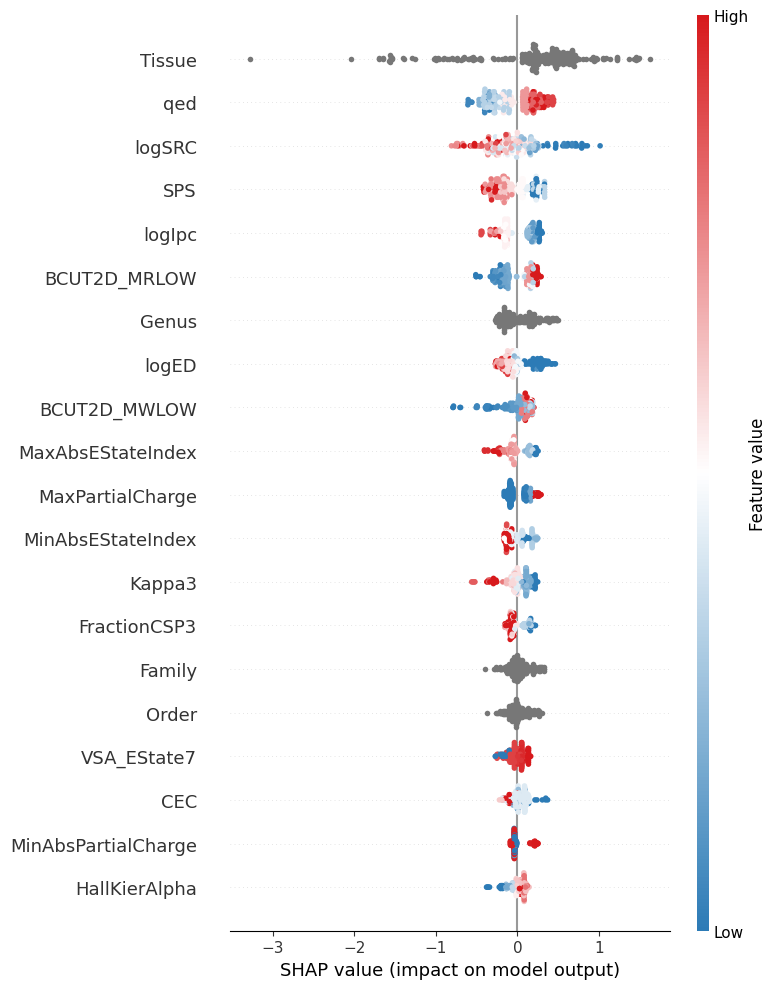

In [ ]:
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "custom_redblue",
    ["#2c7bb6", "#ffffff", "#d7191c"]
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(
    shap_values,
    x_test,
    cmap=cmap,
    max_display=20,     
    plot_size=(8, 10),     
    show=False
)

plt.tight_layout()
#plt.savefig("../../Fig/eps/SHAP_summary.eps",dpi=600)
plt.show()

In [12]:
# Mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": x_test.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(
    "MeanAbsSHAP",
    ascending=False
)

print(shap_importance.to_string(index=False))

            Feature  MeanAbsSHAP
             Tissue     0.588966
                qed     0.249748
             logSRC     0.240046
                SPS     0.201706
             logIpc     0.193117
       BCUT2D_MRLOW     0.189089
              Genus     0.163870
              logED     0.148365
       BCUT2D_MWLOW     0.127561
  MaxAbsEStateIndex     0.124159
   MaxPartialCharge     0.117771
  MinAbsEStateIndex     0.108845
             Kappa3     0.102123
       FractionCSP3     0.092142
             Family     0.089230
              Order     0.083064
        VSA_EState7     0.082866
                CEC     0.073889
MinAbsPartialCharge     0.073458
      HallKierAlpha     0.070725
               Clay     0.069541
   MinPartialCharge     0.065629
                 pH     0.064841
        EState_VSA9     0.047006
                SOC     0.042815
              grass     0.042543
          perennial     0.041176
               Silt     0.039888
          vegetable     0.034960
          

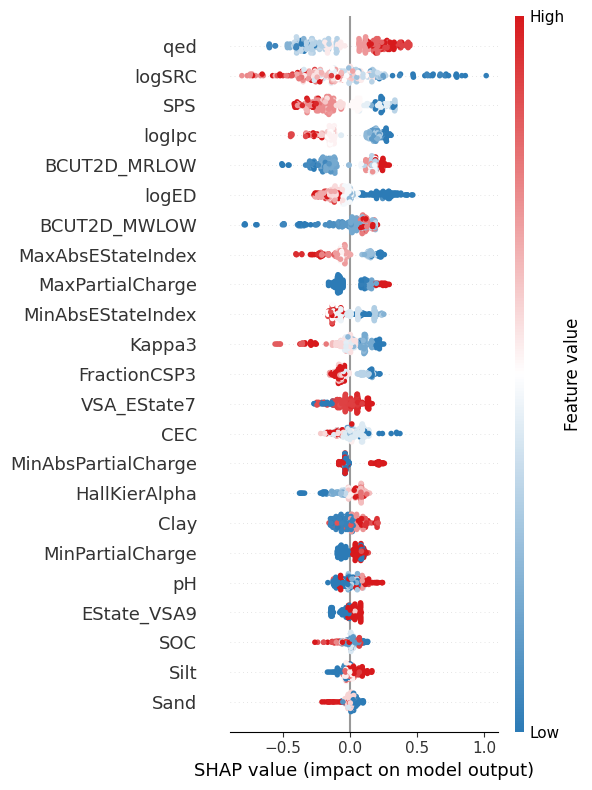

In [ ]:
num_features = [col for col in x_test.columns if col not in cat_cols]

X_num = x_test[num_features]

idx = [x_test.columns.get_loc(col) for col in num_features]
shap_num = shap_values[:, idx]

shap.summary_plot(
    shap_num,
    X_num,
    cmap=cmap,
    max_display=23,
    plot_size=(6, 8),
    show=False
)

plt.tight_layout()
plt.savefig("../../Fig/eps/SHAP_summary_numeric.eps", dpi=600)
plt.show()

In [ ]:
importance = np.abs(shap_num).mean(axis=0)

order = np.argsort(importance)[::-1]
features_sorted = np.array(num_features)[order]
importance_sorted = importance[order]

# ===== 画图 =====
plt.figure(figsize=(6, 8))

plt.barh(features_sorted[::-1], importance_sorted[::-1])

plt.xlabel("mean(|SHAP value|)")

plt.tight_layout()

#plt.savefig("../../Fig/eps/SHAP_importance_numeric.eps", dpi=600)
plt.show()

NameError: name 'shap_num' is not defined


qed


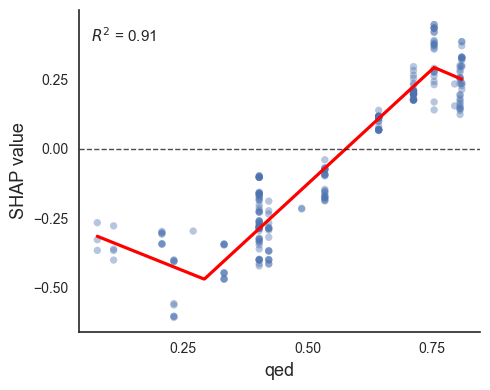

R2 = 0.913
Breakpoints:
[0.077 0.292 0.754 0.809]

SPS


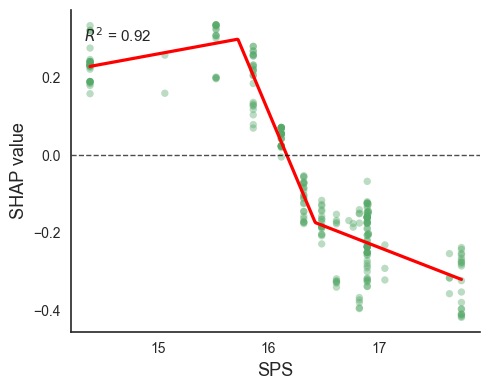

R2 = 0.920
Breakpoints:
[14.385 15.725 16.425 17.75 ]

logIpc


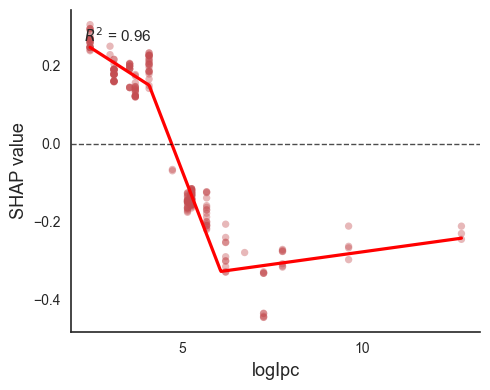

R2 = 0.958
Breakpoints:
[ 2.416  4.062  6.063 12.77 ]

BCUT2D_MRLOW


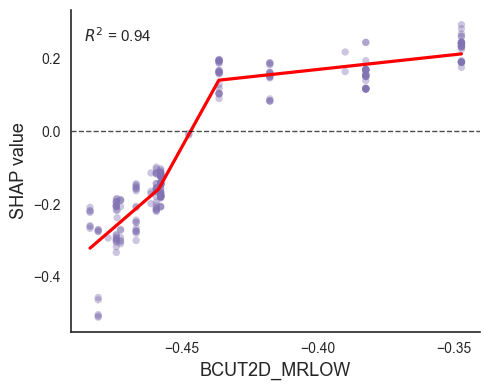

R2 = 0.938
Breakpoints:
[-0.484 -0.459 -0.436 -0.347]

BCUT2D_MWLOW


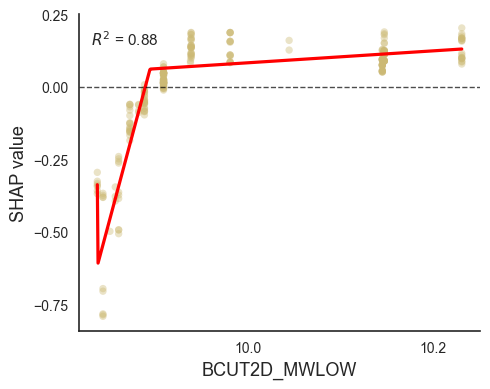

R2 = 0.877
Breakpoints:
[ 9.837  9.838  9.894 10.231]

MaxAbsEStateIndex


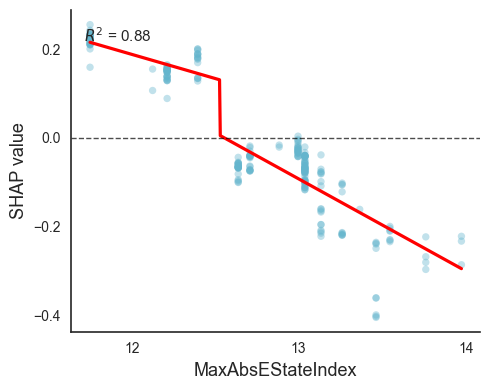

R2 = 0.882
Breakpoints:
[11.751 12.529 12.53  13.975]

MaxPartialCharge


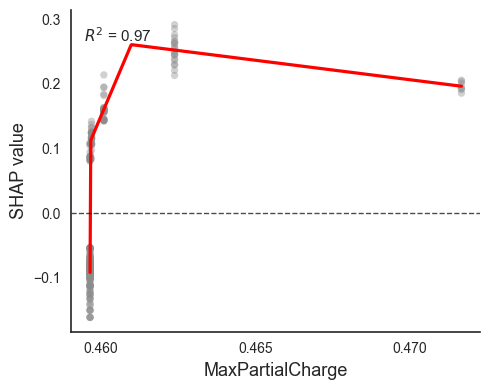

R2 = 0.972
Breakpoints:
[0.46  0.46  0.461 0.472]

Clay


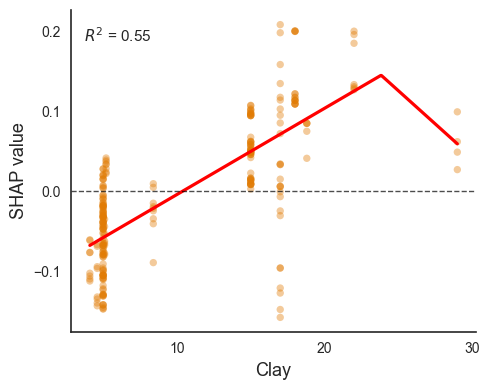

R2 = 0.554
Breakpoints:
[ 4.1   23.838 29.   ]

pH


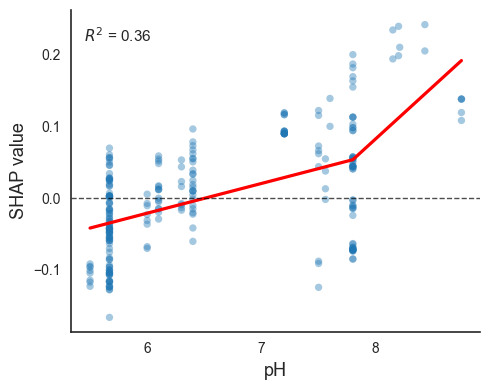

R2 = 0.361
Breakpoints:
[5.5  7.8  8.75]

CEC


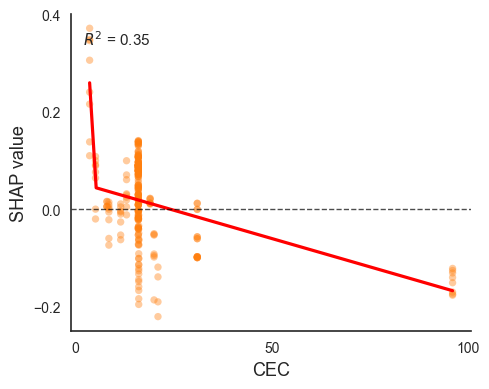

R2 = 0.354
Breakpoints:
[ 3.6   5.25 96.  ]

SOC


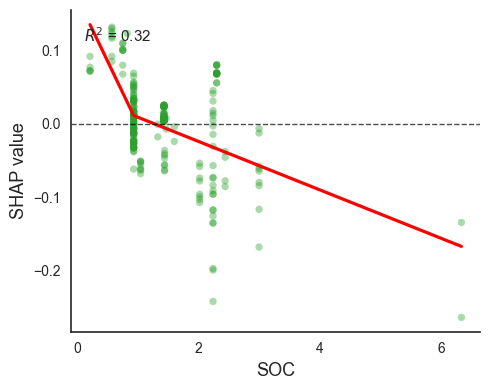

R2 = 0.322
Breakpoints:
[0.21 0.93 6.34]

Silt


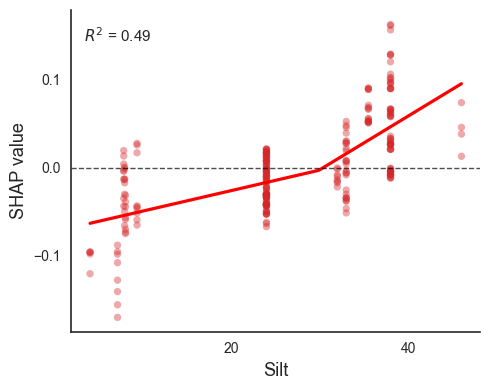

R2 = 0.488
Breakpoints:
[ 4.1   29.912 46.   ]

Sand


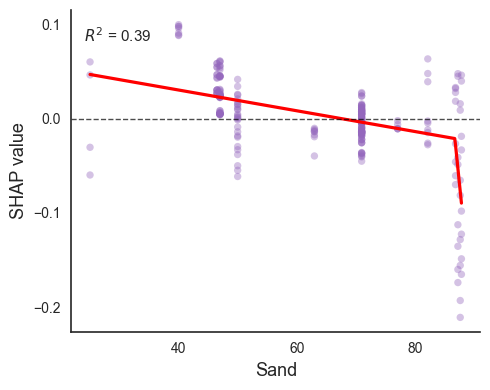

R2 = 0.387
Breakpoints:
[25.    86.787 87.9  ]

logSRC


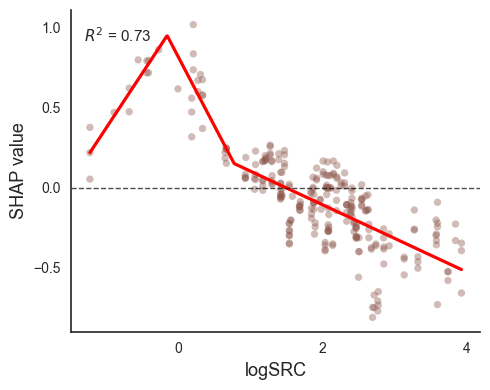

R2 = 0.730
Breakpoints:
[-1.222 -0.151  0.779  3.932]

logED


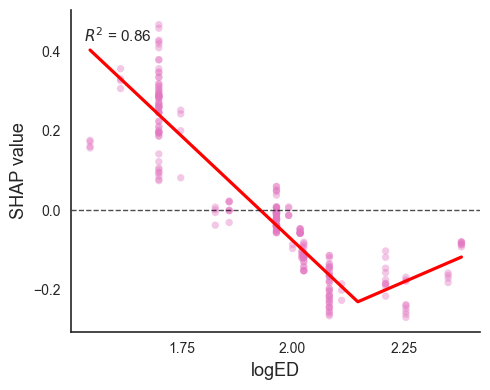

R2 = 0.860
Breakpoints:
[1.544 2.147 2.38 ]


In [19]:
import pwlf

# ==========================================================
# Style
# ==========================================================

plt.rcParams['font.family'] = 'Arial'

sns.set_style("white")

# ==========================================================
# Feature list
# ==========================================================

top_features = [
    "qed",
    "SPS",
    "logIpc",
    "BCUT2D_MRLOW",
    "BCUT2D_MWLOW",
    "MaxAbsEStateIndex",
    "MaxPartialCharge",
    "Clay",
    "pH",
    "CEC",
    "SOC",
    "Silt",
    "Sand",
    "logSRC",
    "logED"
]

# ==========================================================
# Scatter colors
# ==========================================================

colors = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B2",
    "#CCB974",
    "#64B5CD",
    "#8C8C8C",
    "#E17C05",
    "#1F77B4",
    "#FF7F0E",
    "#2CA02C",
    "#D62728",
    "#9467BD",
    "#8C564B",
    "#E377C2"
]

# ==========================================================
# Segment setting
# ==========================================================

segment_dict = {

    "qed": 3,
    "SPS": 3,
    "logIpc": 3,
    "BCUT2D_MRLOW": 3,
    "BCUT2D_MWLOW": 3,
    "MaxAbsEStateIndex": 3,
    "MaxPartialCharge": 3,

    "Clay": 2,
    "pH": 2,
    "CEC": 2,
    "SOC": 2,
    "Silt": 2,
    "Sand": 2,

    "logSRC": 3,
    "logED": 2
}

# ==========================================================
# Loop
# ==========================================================

for i, f in enumerate(top_features):

    print("\n==============================")
    print(f)
    print("==============================")

    # ======================================================
    # Data
    # ======================================================

    x = x_test[f].values

    y = shap_values[
        :,
        x_test.columns.get_loc(f)
    ]

    # ======================================================
    # Remove nan
    # ======================================================

    mask = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x_clean = x[mask]
    y_clean = y[mask]

    # ======================================================
    # Sort
    # ======================================================

    sort_idx = np.argsort(x_clean)

    x_clean = x_clean[sort_idx]
    y_clean = y_clean[sort_idx]

    # ======================================================
    # Piecewise fit
    # ======================================================

    n_segments = segment_dict[f]

    my_pwlf = pwlf.PiecewiseLinFit(
        x_clean,
        y_clean
    )

    breaks = my_pwlf.fit(
        n_segments
    )

    r2 = my_pwlf.r_squared()

    # ======================================================
    # Prediction line
    # ======================================================

    x_hat = np.linspace(
        x_clean.min(),
        x_clean.max(),
        500
    )

    y_hat = my_pwlf.predict(
        x_hat
    )

    # ======================================================
    # Plot
    # ======================================================

    fig, ax = plt.subplots(
        figsize=(5,4)
    )

    # ======================================================
    # Scatter
    # ======================================================

    ax.scatter(

        x_clean,
        y_clean,

        alpha=0.40,
        s=28,

        color=colors[i],

        edgecolors='none'
    )

    # ======================================================
    # Piecewise regression line
    # ======================================================

    ax.plot(

        x_hat,
        y_hat,

        color='red',
        linewidth=2.3
    )

    # ======================================================
    # Zero line
    # ======================================================

    ax.axhline(

        0,

        linestyle='--',
        linewidth=1,

        color='black',
        alpha=0.7
    )

    # ======================================================
    # R2 text
    # ======================================================

    ax.text(

        0.03,
        0.95,

        f"$R^2$ = {r2:.2f}",

        transform=ax.transAxes,

        fontsize=11,

        verticalalignment='top'
    )

    # ======================================================
    # Labels
    # ======================================================

    ax.set_xlabel(
        f,
        fontsize=13
    )

    ax.set_ylabel(
        "SHAP value",
        fontsize=13
    )

    # ======================================================
    # Tick style
    # ======================================================

    ax.tick_params(

        axis='both',

        labelsize=10,

        width=1.2,

        length=4
    )

    # 横坐标不要太密
    ax.locator_params(
        axis='x',
        nbins=4
    )

    ax.locator_params(
        axis='y',
        nbins=5
    )

    # ======================================================
    # Spine style
    # ======================================================

    for spine in ax.spines.values():

        spine.set_linewidth(1.2)

    # ======================================================
    # Remove top/right
    # ======================================================

    sns.despine()

    # ======================================================
    # Tight layout
    # ======================================================

    plt.tight_layout()

    # ======================================================
    # Save
    # ======================================================

    filename = (

        f"../output/shap/"
        f"{f}_piecewise_SHAP.eps"
    )

    # plt.savefig(

    #     filename,

    #     format='eps',

    #     dpi=600,

    #     bbox_inches='tight'
    # )

    plt.show()

    # plt.close()

    # ======================================================
    # Console output
    # ======================================================

    print(f"R2 = {r2:.3f}")

    print("Breakpoints:")

    print(
        np.round(
            breaks,
            3
        )
    )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


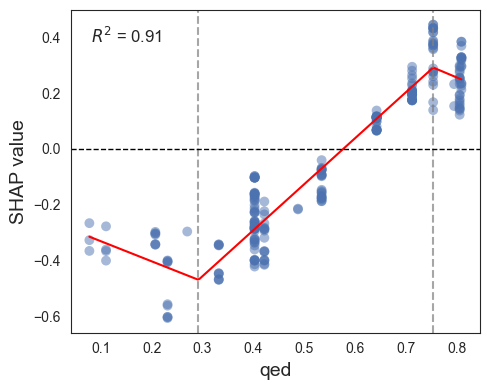

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


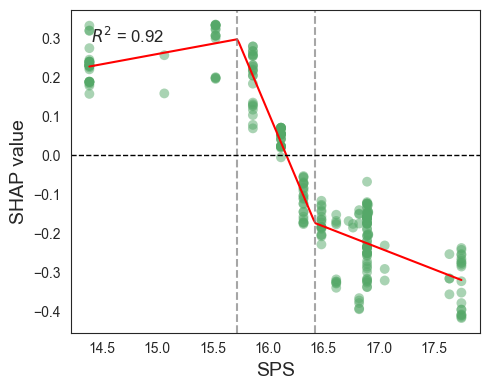

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


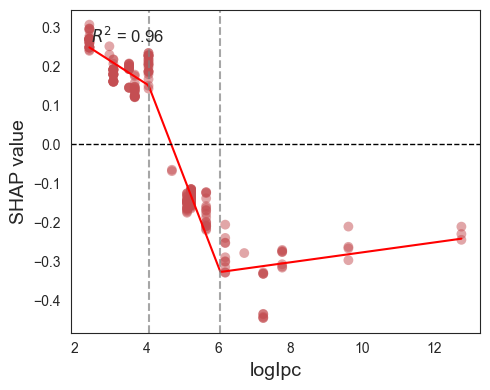

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


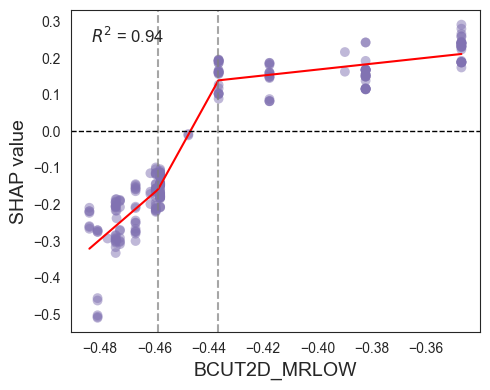

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


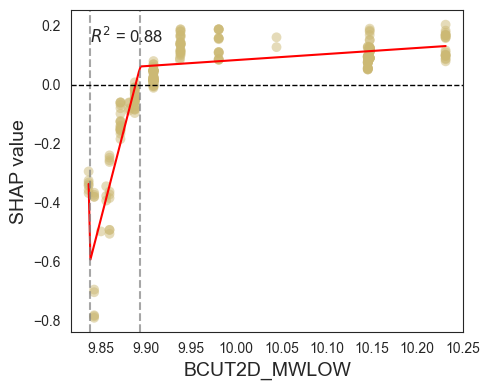

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


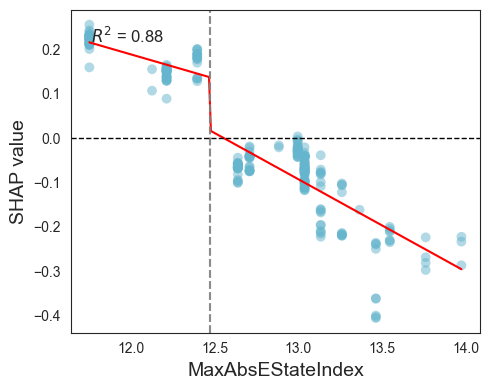

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


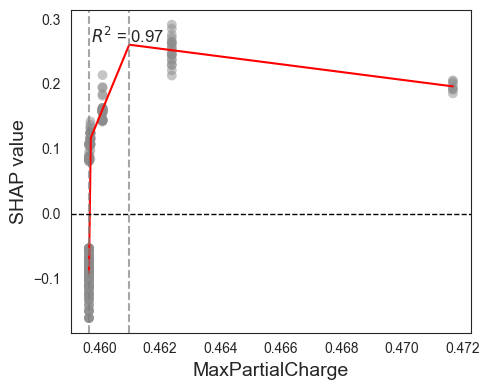

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


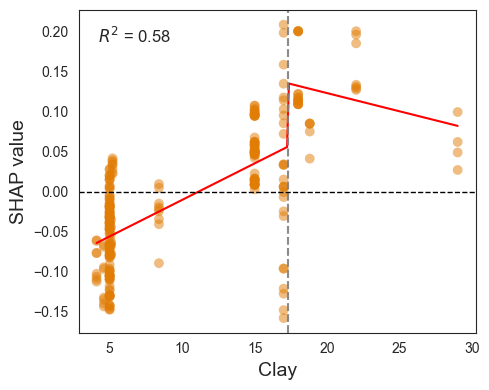

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


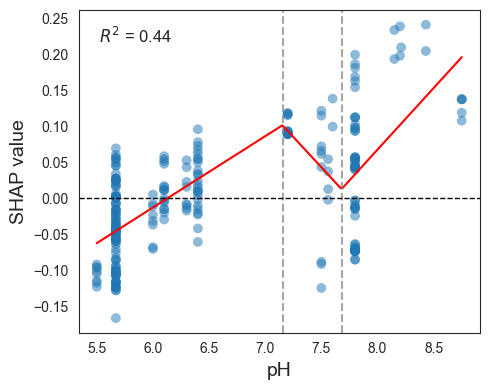

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


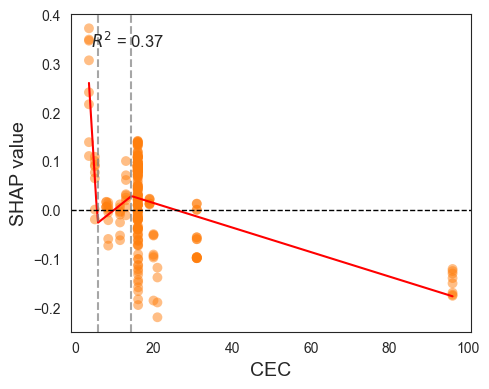

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


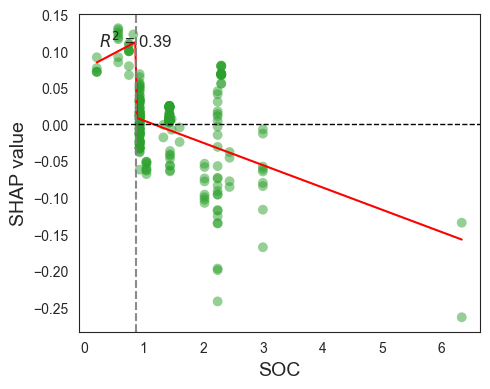

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


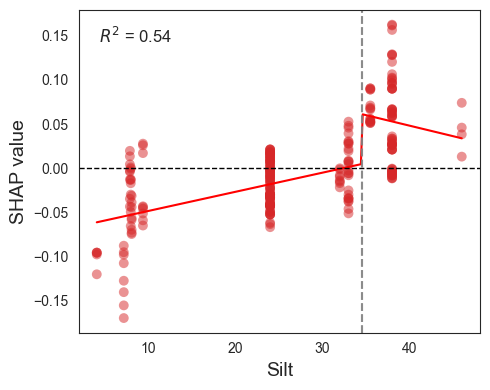

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


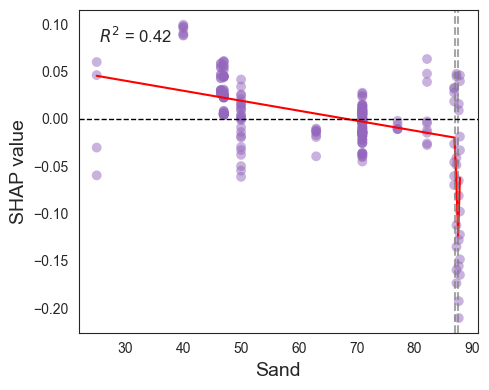

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


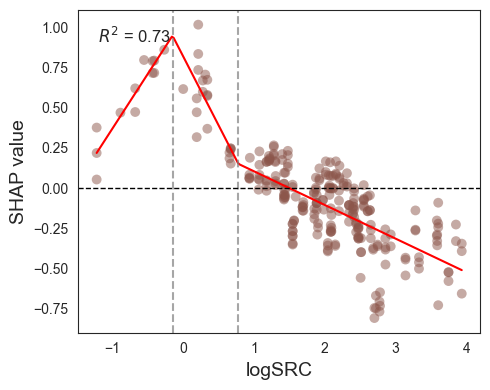

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


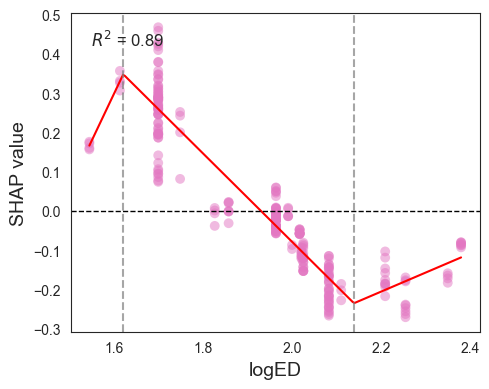

In [20]:
import pwlf

plt.rcParams['font.family'] = 'Arial'

sns.set_style("white")
# ===== 特征列表 =====
top_features = [
    "qed","SPS","logIpc","BCUT2D_MRLOW",
    "BCUT2D_MWLOW","MaxAbsEStateIndex",
    "MaxPartialCharge","Clay","pH",
    'CEC','SOC','Silt','Sand',
    'logSRC','logED'
]

colors = [
    "#4C72B0", "#55A868", "#C44E52",
    "#8172B2", "#CCB974", "#64B5CD",
    "#8C8C8C", "#E17C05", "#1F77B4",
    "#FF7F0E", "#2CA02C", "#D62728",
    "#9467BD", "#8C564B", "#E377C2"
]

# ===== Loop =====
for i, f in enumerate(top_features):

    x = x_test[f].values
    y = shap_values[:, x_test.columns.get_loc(f)]

    # remove nan
    mask = np.isfinite(x) & np.isfinite(y)

    x_clean = x[mask]
    y_clean = y[mask]

    # ===== piecewise linear fit =====
    my_pwlf = pwlf.PiecewiseLinFit(
        x_clean,
        y_clean
    )

    # 3 segments
    breaks = my_pwlf.fit(3)

    r2 = my_pwlf.r_squared()

    x_hat = np.linspace(
        x_clean.min(),
        x_clean.max(),
        200
    )

    y_hat = my_pwlf.predict(x_hat)

    # ===== plot =====
    plt.figure(figsize=(5,4))

    plt.scatter(
        x_clean,
        y_clean,
        alpha=0.5,
        s=50,
        color=colors[i],
        edgecolors='none'
    )

    # piecewise line
    plt.plot(
        x_hat,
        y_hat,
        color='red',
        linewidth=1.5
    )

    # breakpoint vertical lines
    for bp in breaks[1:-1]:

        plt.axvline(
            bp,
            linestyle='--',
            color='grey',
            alpha=0.7
        )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1,
        color='black'
    )

    plt.text(
        0.05,
        0.95,
        f"$R^2$ = {r2:.2f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top'
    )
    plt.xlabel(f, fontsize=14)
    plt.ylabel("SHAP value", fontsize=14)

    plt.tight_layout()

    filename = (
        f"../output/shap/"
        f"{f}_piecewise_SHAP.eps"
    )

    plt.savefig(
        filename,
        format='eps',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()
    #plt.close()

C:\Users\23708\AppData\Local\Temp\ipykernel_35916\571410013.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


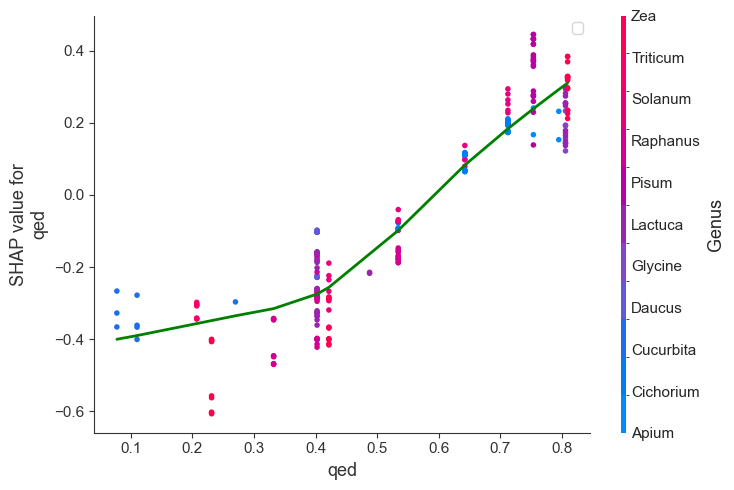

C:\Users\23708\AppData\Local\Temp\ipykernel_35916\571410013.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


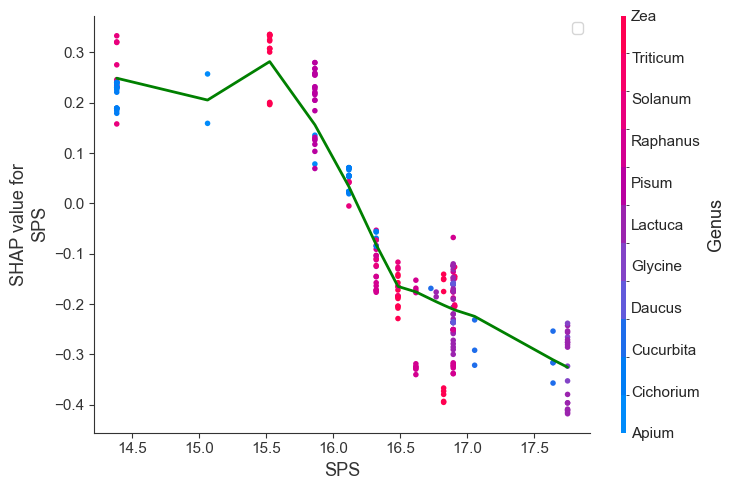

C:\Users\23708\AppData\Local\Temp\ipykernel_35916\571410013.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


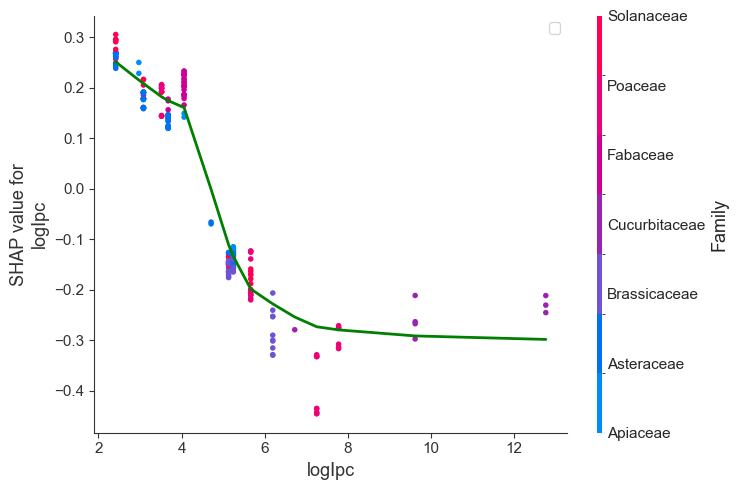

C:\Users\23708\AppData\Local\Temp\ipykernel_35916\571410013.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


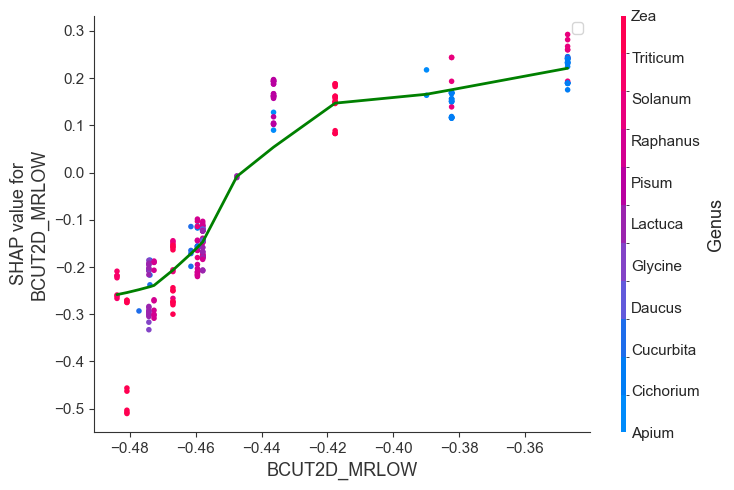

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


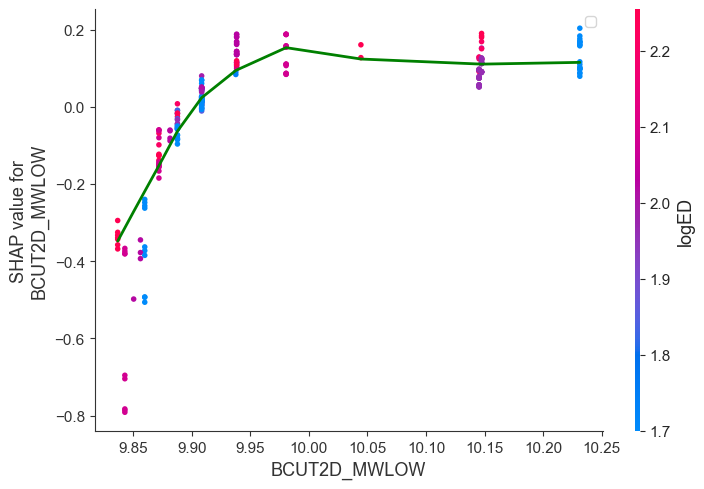

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


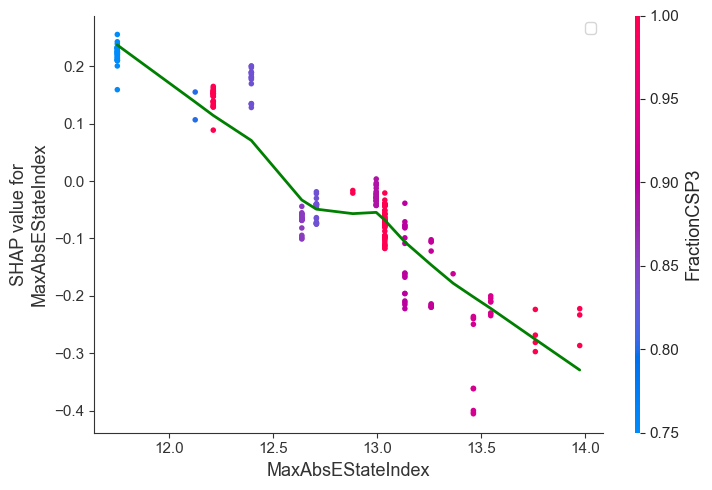

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


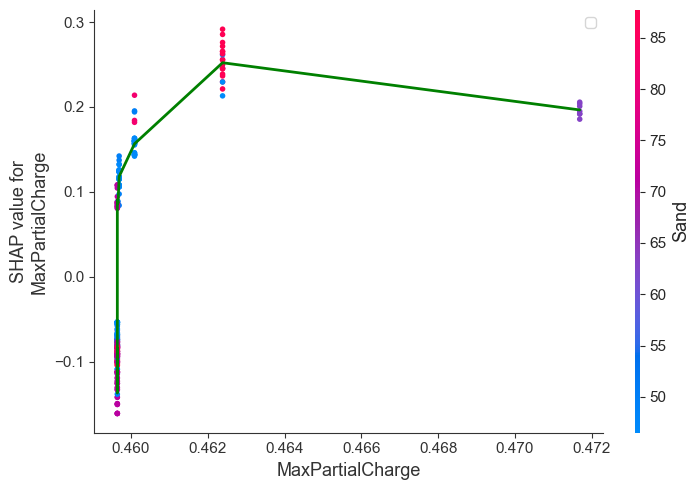

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


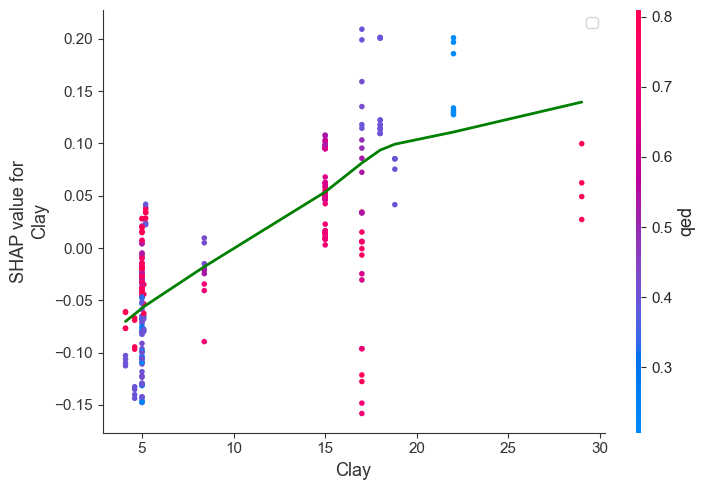

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


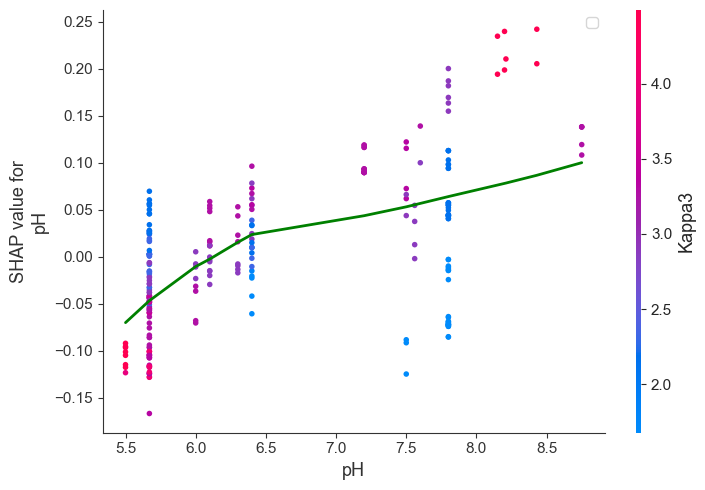

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


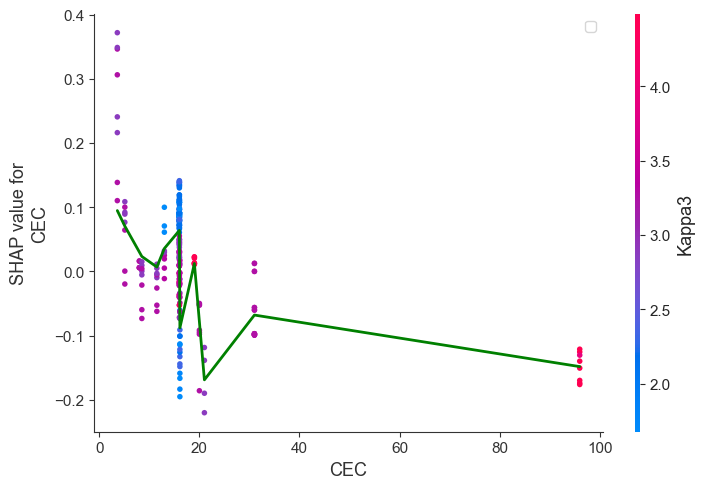

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


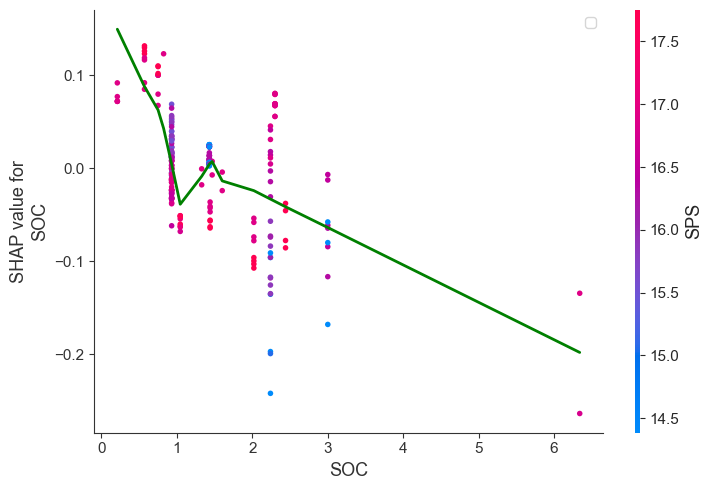

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


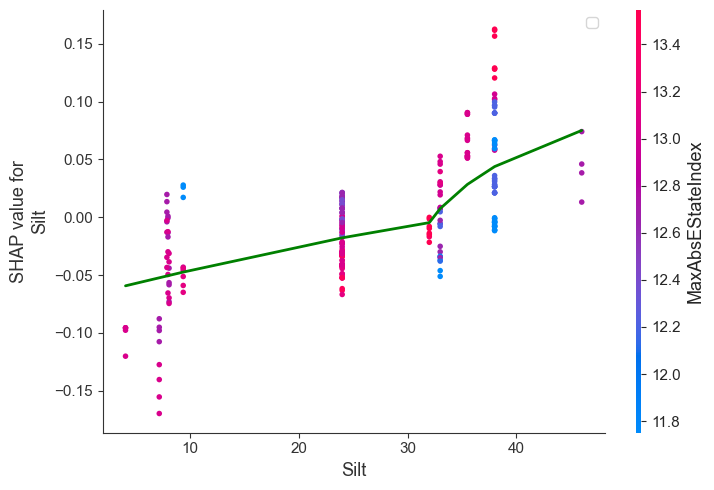

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


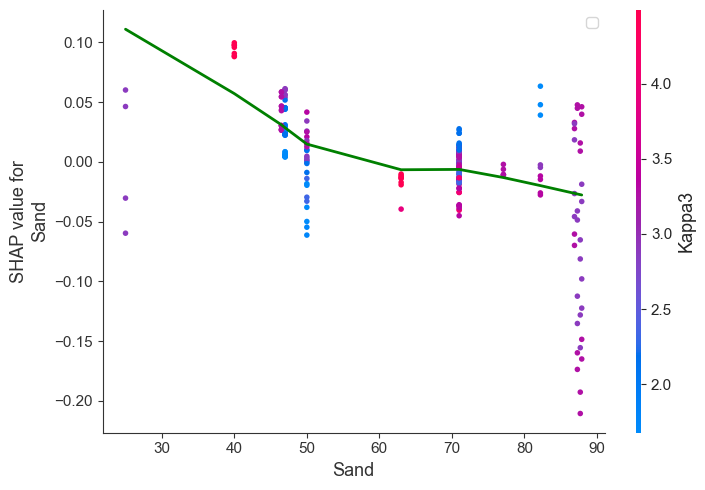

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


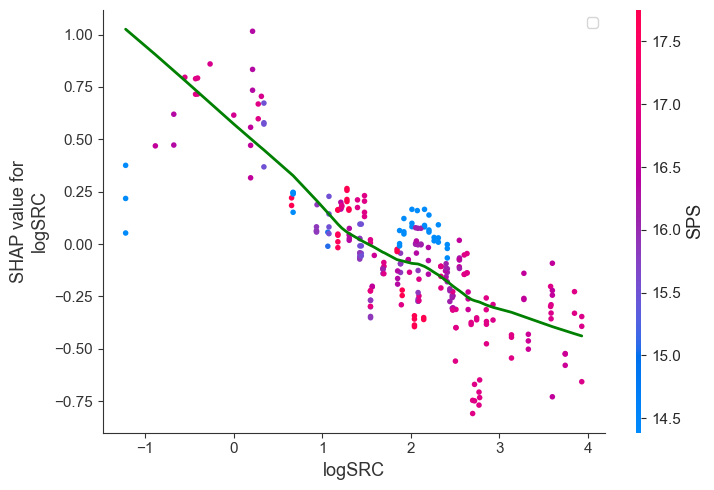

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


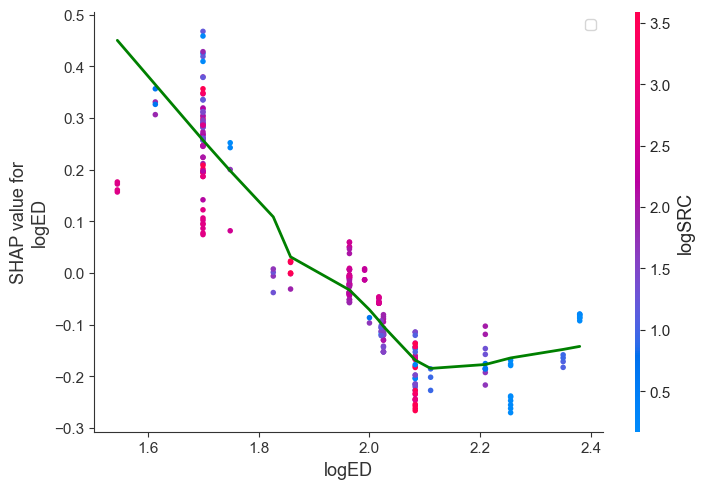

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

top_features = [
    "qed","SPS","logIpc","BCUT2D_MRLOW",
    "BCUT2D_MWLOW","MaxAbsEStateIndex",
    "MaxPartialCharge","Clay","pH",
    'CEC','SOC','Silt','Sand',
    'logSRC','logED'
]

for f in top_features:

    # ========= SHAP dependence plot =========
    shap.dependence_plot(
        f,
        shap_values,
        x_test,
        show=False 
    )

    ax = plt.gca()

    x = x_test[f].values
    idx = x_test.columns.get_loc(f)
    y = shap_values[:, idx]

    smooth = lowess(y, x, frac=0.6)
    x_smooth, y_smooth = smooth[:, 0], smooth[:, 1]

    ax.plot(x_smooth, y_smooth, color="green", linewidth=2)

    ax.legend()

    plt.tight_layout()
    plt.savefig(f"../../Fig/shap/pdp/SHAP_{f}.eps", format="eps", bbox_inches="tight")

    plt.show()


===== SHAP for fruit =====


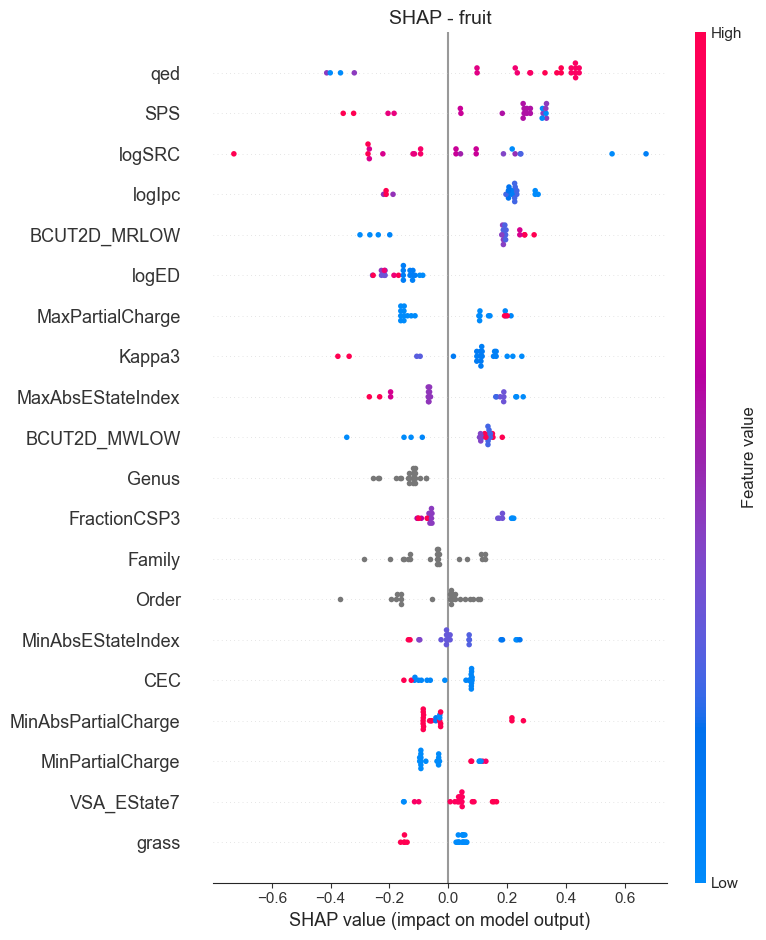


===== SHAP for leaf =====


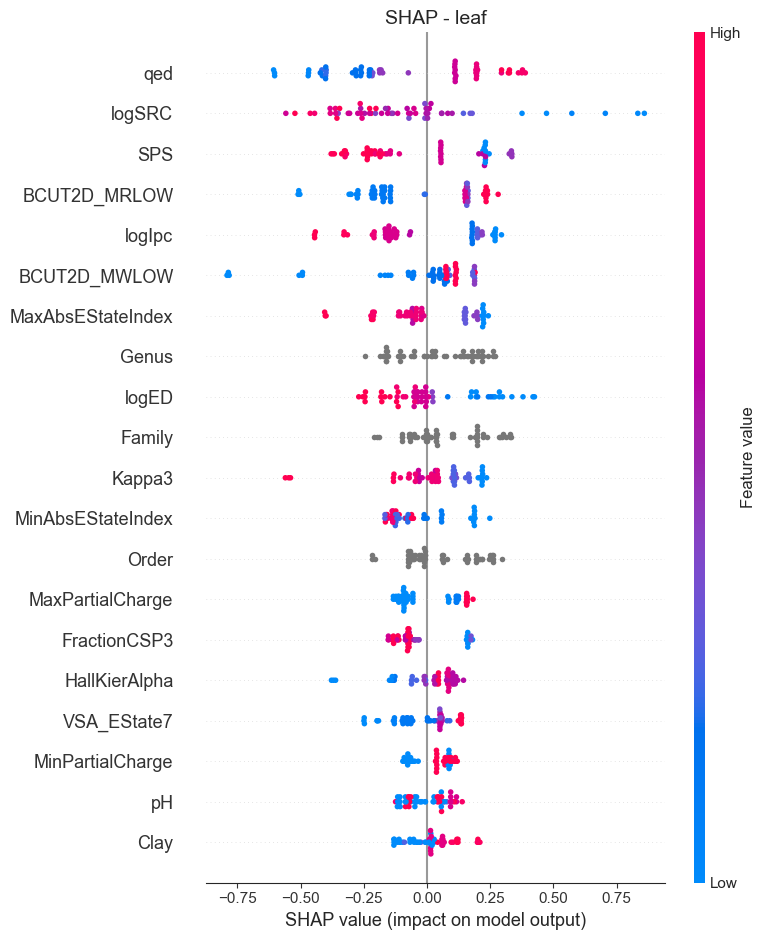


===== SHAP for root =====


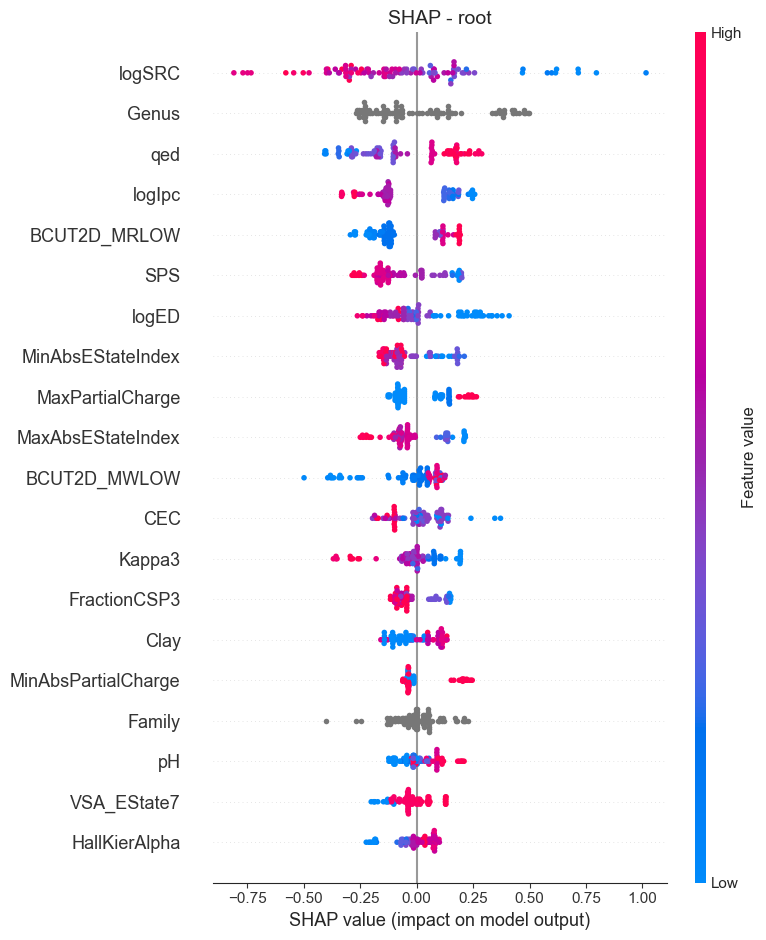


===== SHAP for shoot =====


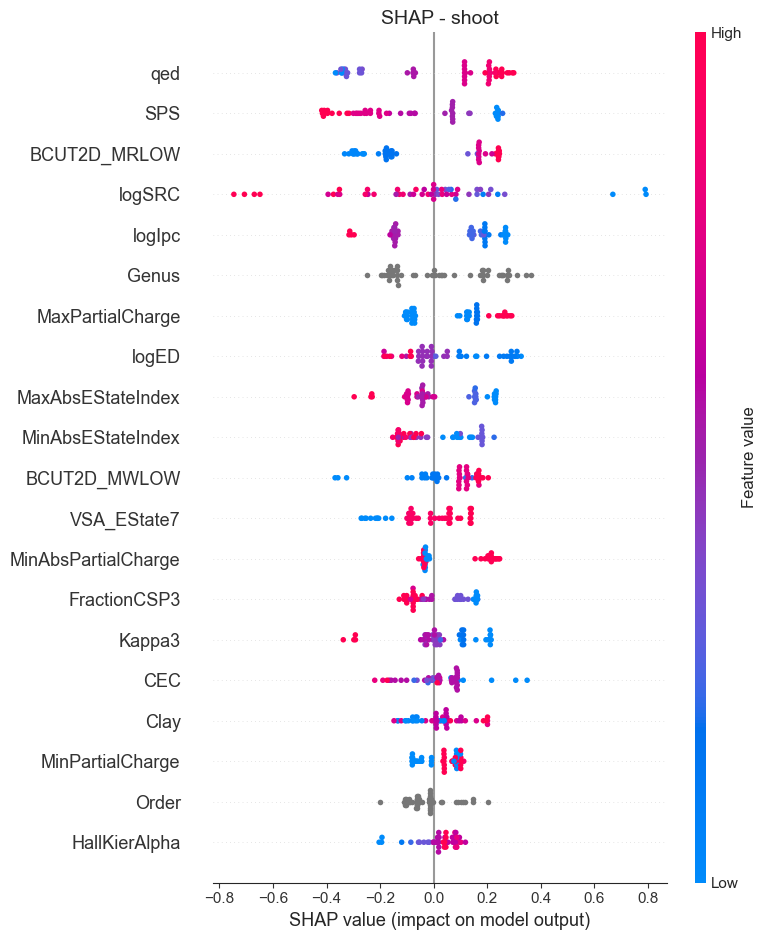


===== SHAP for stem =====


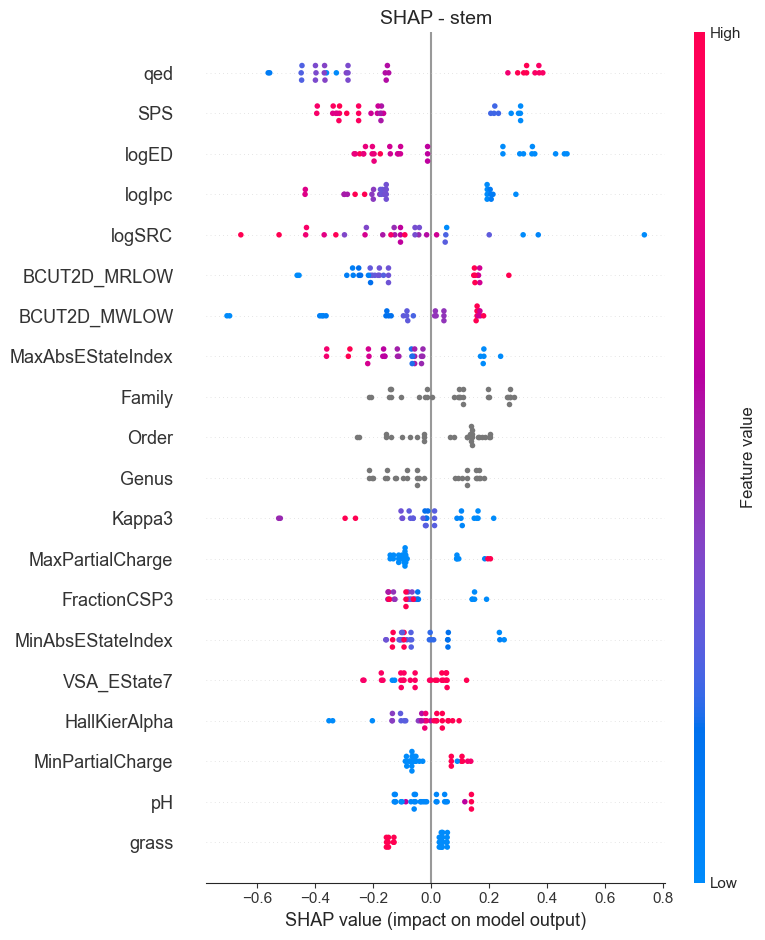

In [ ]:
# Tissue-specific SHAP analysis
tissue_classes = x_test["Tissue"].unique()

for tissue in tissue_classes:

    print(f"\n===== SHAP for {tissue} =====")

    # ======================================================
    # mask
    # ======================================================

    mask = x_test["Tissue"] == tissue

    X_sub = x_test[mask].copy()

    if len(X_sub) < 10:

        continue

    # ======================================================
    # SHAP values
    # ======================================================

    shap_values_sub = explainer.shap_values(
        X_sub
    )

    # ======================================================
    # remove Tissue feature
    # ======================================================

    tissue_idx = X_sub.columns.get_loc(
        "Tissue"
    )

    X_plot = X_sub.drop(
        columns=["Tissue"]
    )

    shap_plot = np.delete(
        shap_values_sub,
        tissue_idx,
        axis=1
    )

    # ======================================================
    # plot
    # ======================================================

    shap.summary_plot(

        shap_plot,

        X_plot,

        show=False
    )

    plt.title(
        f"SHAP - {tissue}",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(

        f"../../Fig/shap/eps/"
        f"SHAP_{tissue}.eps",

        format='eps',

        bbox_inches='tight',

        dpi=600
    )

    plt.show()